The Cybersecurity Intrusion Detection System is a machine learning project that classifies network traffic as normal or malicious using features extracted from network flows. The goal is to detect potential cyber attacks in real-time and enhance network security using models like Decision Tree.

In [ ]:
import pandas as pd

# Load parquet file
test_data = pd.read_parquet("UNSW_NB15_testing-set.parquet")
train_data = pd.read_parquet("UNSW_NB15_train-set.parquet")
# View data
print(df.head())
print(df.shape)
print(df.info())

        dur proto service state  spkts  dpkts  sbytes  dbytes          rate  \
0  0.000011   udp       -   INT      2      0     496       0   90909.09375   
1  0.000008   udp       -   INT      2      0    1762       0  125000.00000   
2  0.000005   udp       -   INT      2      0    1068       0  200000.00000   
3  0.000006   udp       -   INT      2      0     900       0  166666.65625   
4  0.000010   udp       -   INT      2      0    2126       0  100000.00000   

         sload  ...  trans_depth  response_body_len  ct_src_dport_ltm  \
0  180363632.0  ...            0                  0                 1   
1  881000000.0  ...            0                  0                 1   
2  854400000.0  ...            0                  0                 1   
3  600000000.0  ...            0                  0                 2   
4  850400000.0  ...            0                  0                 2   

   ct_dst_sport_ltm  is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  \
0                 1

In [ ]:
df.columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt',
       'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports',
       'attack_cat', 'label'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   dur                82332 non-null  float32 
 1   proto              82332 non-null  category
 2   service            82332 non-null  category
 3   state              82332 non-null  category
 4   spkts              82332 non-null  int16   
 5   dpkts              82332 non-null  int16   
 6   sbytes             82332 non-null  int32   
 7   dbytes             82332 non-null  int32   
 8   rate               82332 non-null  float32 
 9   sload              82332 non-null  float32 
 10  dload              82332 non-null  float32 
 11  sloss              82332 non-null  int16   
 12  dloss              82332 non-null  int16   
 13  sinpkt             82332 non-null  float32 
 14  dinpkt             82332 non-null  float32 
 15  sjit               82332 non-null  float32 
 16  djit

In [11]:
# Check target distribution
print(df['label'].value_counts())

# Check missing values
print(df.isnull().sum())

# Check columns
print(df.columns)

label
1    45332
0    37000
Name: count, dtype: int64
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
attack_cat           0
label                0
dtype: int64
Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sload', 

Text(0.5, 1.0, 'Normal vs Attack')

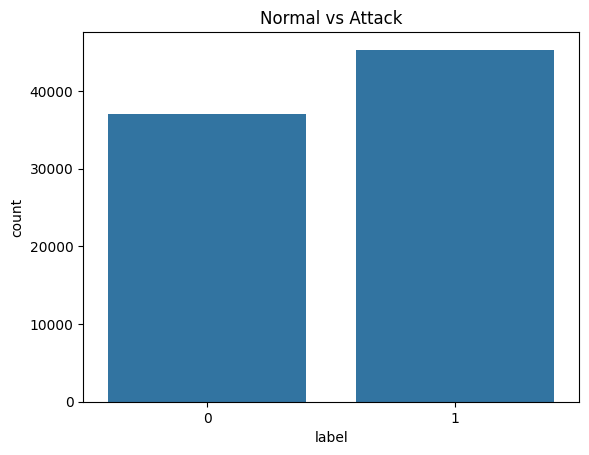

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label',data=df)
plt.title("Normal vs Attack")


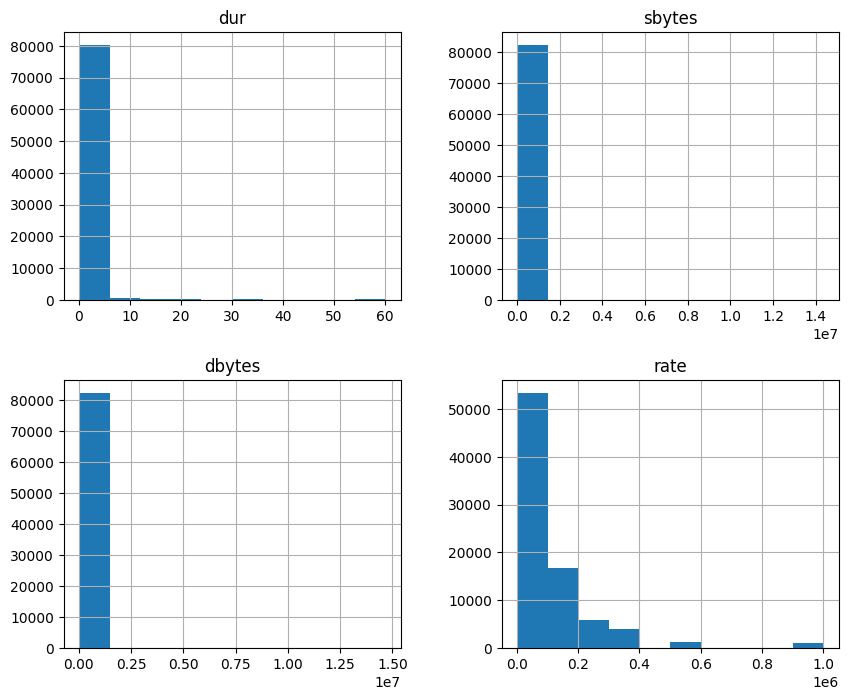

In [15]:
df[['dur', 'sbytes', 'dbytes', 'rate']].hist(figsize=(10,8))
plt.show()

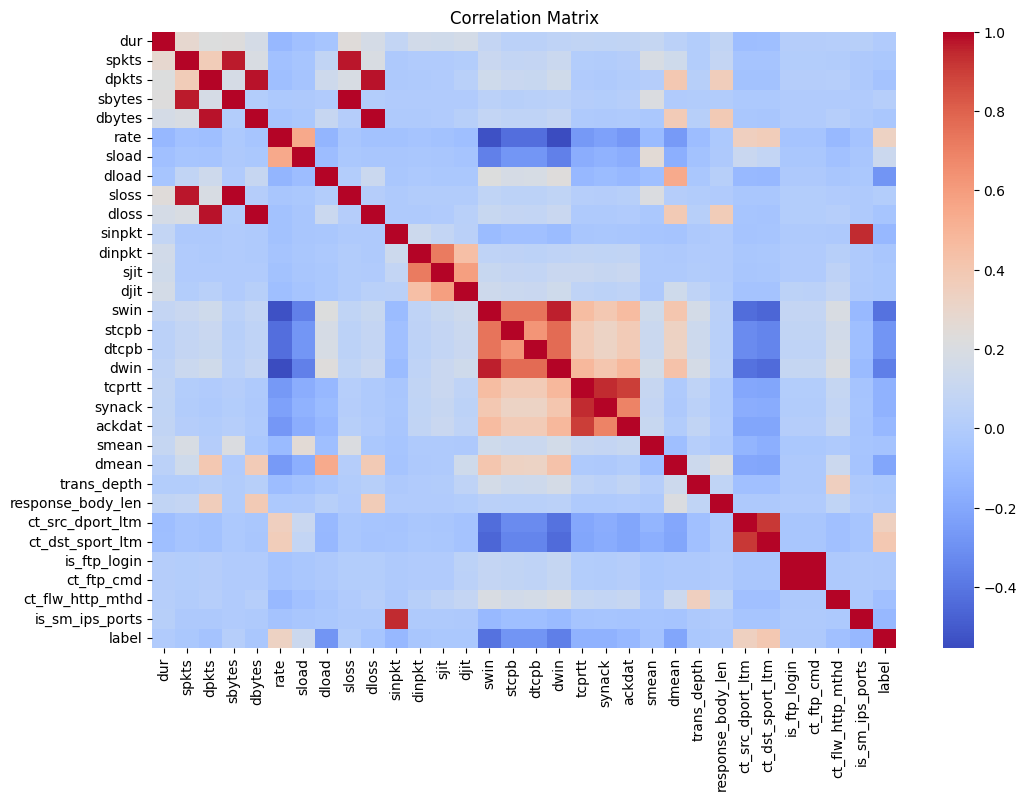

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

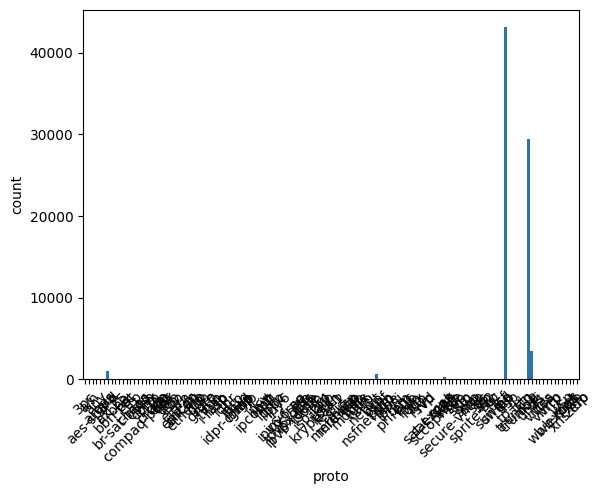

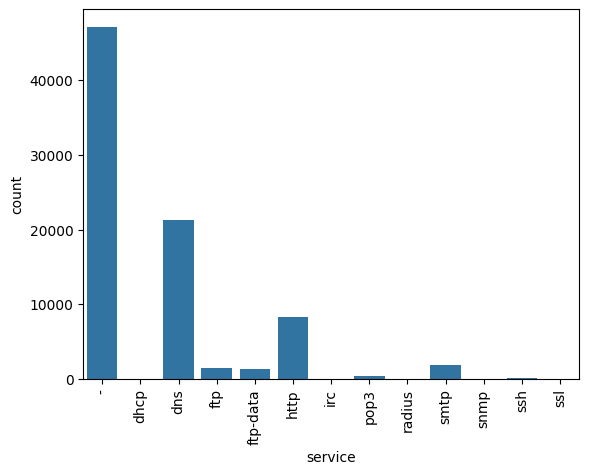

In [17]:
sns.countplot(x='proto', data=df)
plt.xticks(rotation=45)
plt.show()

sns.countplot(x='service', data=df)
plt.xticks(rotation=90)
plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['proto', 'service', 'state']:
    df[col] = le.fit_transform(df[col])


In [18]:
df['proto'].unique()

['udp', 'arp', 'tcp', 'igmp', 'ospf', ..., 'sccopmce', 'iplt', 'pipe', 'sps', 'ib']
Length: 131
Categories (131, object): ['3pc', 'a/n', 'aes-sp3-d', 'any', ..., 'xnet', 'xns-idp', 'xtp', 'zero']

In [20]:
# Example (adjust if needed)
df = df.drop(['id'], axis=1, errors='ignore')

In [21]:
X = df.drop(['label', 'attack_cat'], axis=1, errors='ignore')
y = df['label']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
X

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports
0,0.000011,117,0,4,2,0,496,0,90909.093750,1.803636e+08,...,248,0,0,0,1,1,0,0,0,0
1,0.000008,117,0,4,2,0,1762,0,125000.000000,8.810000e+08,...,881,0,0,0,1,1,0,0,0,0
2,0.000005,117,0,4,2,0,1068,0,200000.000000,8.544000e+08,...,534,0,0,0,1,1,0,0,0,0
3,0.000006,117,0,4,2,0,900,0,166666.656250,6.000000e+08,...,450,0,0,0,2,1,0,0,0,0
4,0.000010,117,0,4,2,0,2126,0,100000.000000,8.504000e+08,...,1063,0,0,0,2,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82327,0.000005,117,0,4,2,0,104,0,200000.000000,8.320000e+07,...,52,0,0,0,1,1,0,0,0,0
82328,1.106101,111,0,3,20,8,18062,354,24.410067,1.241044e+05,...,903,44,0,0,1,1,0,0,0,0
82329,0.000000,6,0,4,1,0,46,0,0.000000,0.000000e+00,...,46,0,0,0,1,1,0,0,0,1
82330,0.000000,6,0,4,1,0,46,0,0.000000,0.000000e+00,...,46,0,0,0,1,1,0,0,0,1


In [25]:
print(y.value_counts(normalize=True))

label
1    0.5506
0    0.4494
Name: proportion, dtype: float64


In [26]:
# simple
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# baseline model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# predictions
y_pred = dt.predict(X_test)

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9300419019857897

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92      7418
           1       0.94      0.93      0.94      9049

    accuracy                           0.93     16467
   macro avg       0.93      0.93      0.93     16467
weighted avg       0.93      0.93      0.93     16467



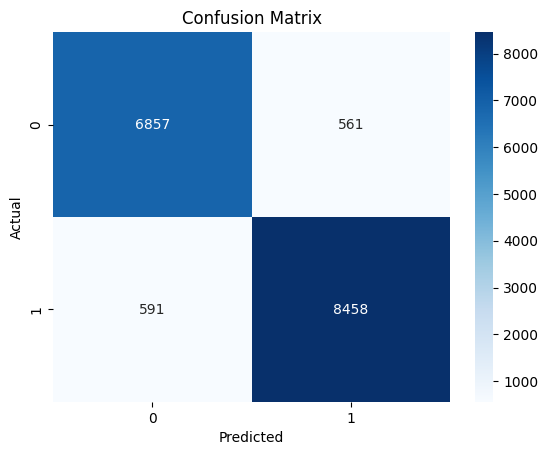

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

<!-- hyper -->

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',   # important for imbalance
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [29]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nReport:\n", classification_report(y_test, y_pred_best))

Accuracy: 0.9331997327989312

Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93      7418
           1       0.97      0.91      0.94      9049

    accuracy                           0.93     16467
   macro avg       0.93      0.94      0.93     16467
weighted avg       0.94      0.93      0.93     16467



In [30]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(10))

             feature  importance
29  ct_dst_sport_ltm    0.293097
10             dload    0.099933
6             sbytes    0.095563
7             dbytes    0.072696
1              proto    0.072375
21            tcprtt    0.067764
11             sloss    0.051072
24             smean    0.038320
2            service    0.036954
22            synack    0.036258


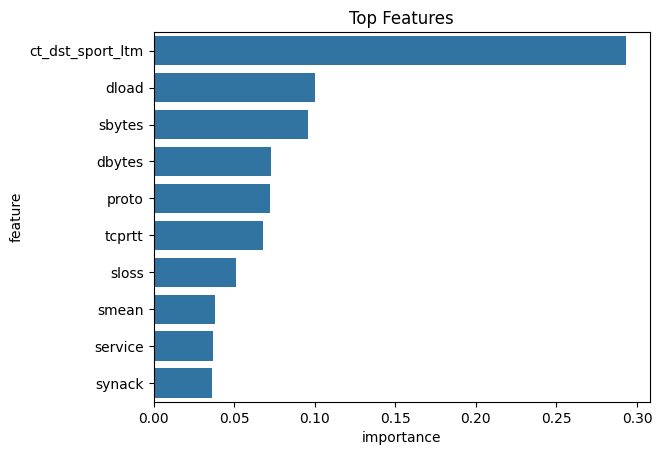

In [31]:
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title("Top Features")
plt.show()

In [32]:
print("Train Accuracy:", best_model.score(X_train, y_train))
print("Test Accuracy:", best_model.score(X_test, y_test))

Train Accuracy: 0.9523267289152053
Test Accuracy: 0.9331997327989312


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

print("RF Accuracy:", rf.score(X_test, y_test))

RF Accuracy: 0.9464990587235076


<!-- save -->

In [36]:
import joblib
proto_enc = le 
service_enc = le 
state_enc = le 
joblib.dump(best_model, "model.pkl")
joblib.dump(proto_enc, "proto_enc.pkl")
joblib.dump(service_enc, "service_enc.pkl")
joblib.dump(state_enc, "state_enc.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

load

In [56]:
import pandas as pd
import joblib

# Load saved objects
model = joblib.load("model.pkl")
proto_enc = joblib.load("proto_enc.pkl")
service_enc = joblib.load("service_enc.pkl")
state_enc = joblib.load("state_enc.pkl")
columns = joblib.load("columns.pkl")

# 🔹 Example user input
user_input0 = {
    'dur': 0.5,                  # longer duration
    'proto': 'udp',
    'service': 'dns',
    'state': 'INT',

    'spkts': 50,
    'dpkts': 2,
    'sbytes': 50000,
    'dbytes': 10,
    'rate': 500000.0,
    'sload': 999999999.0,

    'trans_depth': 5,
    'response_body_len': 2000,
    'ct_src_dport_ltm': 10,
    'ct_dst_sport_ltm': 8,
    'is_ftp_login': 1,
    'ct_ftp_cmd': 3,
    'ct_flw_http_mthd': 5,
    'is_sm_ips_ports': 1
}

user_input1 = {
    'dur': 0.921987,
    'proto': 'ospf',
    'service': '-',
    'state': 'INT',

    'spkts': 20,
    'dpkts': 0,
    'sbytes': 1280,
    'dbytes': 0,
    'rate': 20.607666,
    'sload': 10551.12,

    'trans_depth': 0,
    'response_body_len': 0,
    'ct_src_dport_ltm': 1,
    'ct_dst_sport_ltm': 1,
    'is_ftp_login': 0,
    'ct_ftp_cmd': 0,
    'ct_flw_http_mthd': 0,
    'is_sm_ips_ports': 0
}

# Convert to DataFrame
input_df = pd.DataFrame([user_input1])

# 🔁 Safe encoding function
def safe_transform(encoder, value):
    return encoder.transform([value])[0] if value in encoder.classes_ else -1

# Apply encoding
input_df['proto'] = safe_transform(proto_enc, input_df['proto'][0])
input_df['service'] = safe_transform(service_enc, input_df['service'][0])
input_df['state'] = safe_transform(state_enc, input_df['state'][0])

# Match training columns
input_df = input_df.reindex(columns=columns, fill_value=0)

# Prediction
prediction = model.predict(input_df)[0]

# Output
if prediction == 0:
    print("✅ Normal Traffic")
else:
    print("🚨 Attack Detected!")

✅ Normal Traffic


c:\Users\malik\Desktop\ML_Revise\.myenv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [40]:
df.head(3)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.000011,117,0,4,2,0,496,0,90909.09375,180363632.0,...,0,0,1,1,0,0,0,0,Normal,0
1,0.000008,117,0,4,2,0,1762,0,125000.00000,881000000.0,...,0,0,1,1,0,0,0,0,Normal,0
2,0.000005,117,0,4,2,0,1068,0,200000.00000,854400000.0,...,0,0,1,1,0,0,0,0,Normal,0


In [54]:
df.head(4)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.000011,117,0,4,2,0,496,0,90909.09375,180363632.0,...,0,0,1,1,0,0,0,0,Normal,0
1,0.000008,117,0,4,2,0,1762,0,125000.00000,881000000.0,...,0,0,1,1,0,0,0,0,Normal,0
2,0.000005,117,0,4,2,0,1068,0,200000.00000,854400000.0,...,0,0,1,1,0,0,0,0,Normal,0
3,0.000006,117,0,4,2,0,900,0,166666.65625,600000000.0,...,0,0,2,1,0,0,0,0,Normal,0
